# Computer Vision --- Lecture 3 Hands-On
## Image Classification & Linear Models


Today we build a complete classifier: score function, loss, analytic gradient,
and a training loop. No autograd, no framework -- just NumPy, so that when you do
use PyTorch next week you know exactly what it is doing for you.

| Section | Topic |
|---|---|
| 0 | Data, splits, preprocessing |
| 1 | $k$-NN: naive vs vectorized, and why it fails on pixels |
| 2 | The linear score function |
| 3 | Softmax loss: loops, then vectorized |
| 4 | Multi-label: independent sigmoids |
| 5 | The analytic gradient, and checking it |
| 6 | Training with SGD |
| 7 | Learning rate, regularization, and what the weights look like |
| 8 | Sanity checks |
| 9 | The same model in PyTorch |

Cells marked **TODO** are for you. Exercises at the end.

---
## 0. Data

We use sklearn's bundled `digits`: 1797 images of 8x8 pixels, 10 classes. Small enough
that every experiment below runs in seconds, which is the point -- you should be able to
try twenty things in this session.

The pipeline is identical for CIFAR-10; only the numbers change.

In [1]:
# !pip install numpy matplotlib scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

np.set_printoptions(precision=4, suppress=True, linewidth=120)
plt.rcParams["figure.figsize"] = (10, 3.5)
rng = np.random.default_rng(0)

train (1078, 64)   val (359, 64)   test (360, 64)
class counts (train): [107 109 106 110 109 109 109 107 104 108]


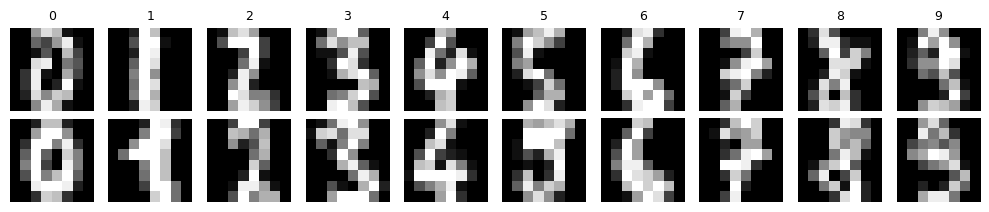

In [2]:
digits = load_digits()
X_all = digits.data / 16.0                 # (1797, 64), values in [0, 1]
y_all = digits.target
C = 10

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_all, y_all, test_size=0.4,
                                            random_state=0, stratify=y_all)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5,
                                            random_state=0, stratify=y_tmp)

print(f"train {X_tr.shape}   val {X_val.shape}   test {X_te.shape}")
print("class counts (train):", np.bincount(y_tr))

fig, axes = plt.subplots(2, 10, figsize=(10, 2.2))
for c in range(10):
    idx = np.where(y_tr == c)[0][:2]
    for r in range(2):
        axes[r, c].imshow(X_tr[idx[r]].reshape(8, 8), cmap="gray")
        axes[r, c].axis("off")
    axes[0, c].set_title(c, fontsize=9)
plt.tight_layout(); plt.show()

### Preprocessing

Compute the mean on the **training set only**, then apply the same vector to val and test.
Computing it over all the data is a leak -- small here, fatal in a paper.

D = 65  (64 pixels + 1 bias column)
a linear classifier here has C*D = 650 parameters
for CIFAR-10 it would be 10 * 3073 = 30730


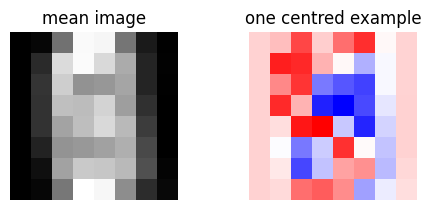

In [3]:
mu = X_tr.mean(axis=0)                       # training statistics only

def prep(X, mu):
    """Centre, then append the bias column."""
    Xc = X - mu
    return np.hstack([Xc, np.ones((len(Xc), 1))])

Xtr, Xval, Xte = prep(X_tr, mu), prep(X_val, mu), prep(X_te, mu)
D = Xtr.shape[1]
print(f"D = {D}  (64 pixels + 1 bias column)")
print(f"a linear classifier here has C*D = {C*D} parameters")
print(f"for CIFAR-10 it would be 10 * 3073 = {10*3073}")

fig, ax = plt.subplots(1, 2, figsize=(5, 2.2))
ax[0].imshow(mu.reshape(8, 8), cmap="gray"); ax[0].set_title("mean image")
ax[1].imshow((X_tr[0] - mu).reshape(8, 8), cmap="bwr"); ax[1].set_title("one centred example")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

---
## 1. $k$-Nearest Neighbours

Start with the loop version, because it is obviously correct. Then vectorize it, because
the loop version is unusable.

The trick for the vectorized form:

$$\|a - b\|^2 = \|a\|^2 + \|b\|^2 - 2\,a^{\top}b$$

so a full $N_{\text{test}} \times N_{\text{train}}$ distance matrix is one matrix product
plus two broadcasts.

In [4]:
def dists_loops(A, B):
    """Naive: one Python loop iteration per pair."""
    d = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            d[i, j] = np.sqrt(((A[i] - B[j]) ** 2).sum())
    return d


def dists_half(A, B):
    """One loop, broadcasting inside."""
    d = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        d[i] = np.sqrt(((B - A[i]) ** 2).sum(axis=1))
    return d


def dists_vectorized(A, B):
    """No loops: ||a-b||^2 = ||a||^2 + ||b||^2 - 2 a.b"""
    a2 = (A ** 2).sum(axis=1)[:, None]
    b2 = (B ** 2).sum(axis=1)[None, :]
    d2 = a2 + b2 - 2 * A @ B.T
    return np.sqrt(np.maximum(d2, 0))        # clamp: -1e-15 would give nan

In [5]:
A, B = X_val[:120], X_tr[:400]


def timeit(fn, repeats=None):
    """Median of several runs, using a high-resolution clock.

    time.time() has ~15 ms granularity on Windows, so a fast call can measure as
    exactly 0.0 -- and then a speed-up ratio divides by zero. perf_counter is
    monotonic and sub-microsecond; repeating guards against a single noisy run.
    """
    t = time.perf_counter()
    out = fn()
    first = time.perf_counter() - t
    if repeats is None:                      # cheap calls get timed more often
        repeats = 1 if first > 0.05 else 20
    times = [first]
    for _ in range(repeats - 1):
        t = time.perf_counter(); fn(); times.append(time.perf_counter() - t)
    return out, float(np.median(times))


d0, t_loops = timeit(lambda: dists_loops(A, B))
d1, t_half  = timeit(lambda: dists_half(A, B))
d2, t_vec   = timeit(lambda: dists_vectorized(A, B))

def speedup(slow, fast):
    return f"{slow/fast:6.1f}x" if fast > 0 else "   n/a"

print(f"two loops : {t_loops*1000:8.2f} ms")
print(f"one loop  : {t_half*1000:8.2f} ms   ({speedup(t_loops, t_half)})")
print(f"vectorized: {t_vec*1000:8.2f} ms   ({speedup(t_loops, t_vec)})")
print(f"\nmax |difference|: {np.abs(d0 - d2).max():.2e}")

two loops :   155.54 ms
one loop  :     3.07 ms   (  50.6x)
vectorized:     0.43 ms   ( 361.5x)

max |difference|: 0.00e+00


Two things to take from those timings.

The big step is getting the per-pair work out of Python: removing the inner loop is worth
an order of magnitude on its own. Removing the outer loop as well turns the whole
computation into one matrix product -- which is the operation BLAS and GPUs are built for,
so the advantage grows with problem size rather than staying fixed. (Run the cell twice;
the ratios move around, which is itself worth knowing about micro-benchmarks.)

Also note the `np.maximum(d2, 0)`. Floating-point cancellation can make a squared distance
very slightly negative, and `np.sqrt(-1e-16)` is `nan`. This is a real bug that bites
people writing this exact function.

k =  1   validation accuracy = 0.9916
k =  3   validation accuracy = 0.9916
k =  5   validation accuracy = 0.9916
k =  7   validation accuracy = 0.9833
k = 10   validation accuracy = 0.9749
k = 15   validation accuracy = 0.9554
k = 20   validation accuracy = 0.9582
k = 30   validation accuracy = 0.9415
k = 50   validation accuracy = 0.9164

best k = 1


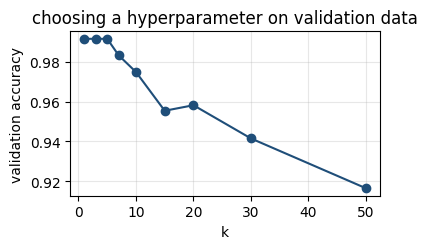

In [6]:
def knn_predict(Xtrain, ytrain, Xquery, k=1):
    d = dists_vectorized(Xquery, Xtrain)
    nn = np.argsort(d, axis=1)[:, :k]                    # k closest
    votes = ytrain[nn]                                   # (Nq, k)
    return np.array([np.bincount(v, minlength=C).argmax() for v in votes])


ks = [1, 3, 5, 7, 10, 15, 20, 30, 50]
accs = [(knn_predict(Xtr, y_tr, Xval, k) == y_val).mean() for k in ks]

for k, a in zip(ks, accs):
    print(f"k = {k:2d}   validation accuracy = {a:.4f}")
best_k = ks[int(np.argmax(accs))]
print(f"\nbest k = {best_k}")

plt.figure(figsize=(4, 2.6))
plt.plot(ks, accs, "o-", color="#1F4E79")
plt.xlabel("k"); plt.ylabel("validation accuracy"); plt.grid(alpha=.3)
plt.title("choosing a hyperparameter on validation data")
plt.tight_layout(); plt.show()

Note that the best $k$ here is 1, at the very edge of the grid. Whenever the best
hyperparameter sits at a boundary of your search range, **extend the range** -- you have
not found an optimum, you have found the end of your grid. The same applies to $\lambda$
later in this notebook.

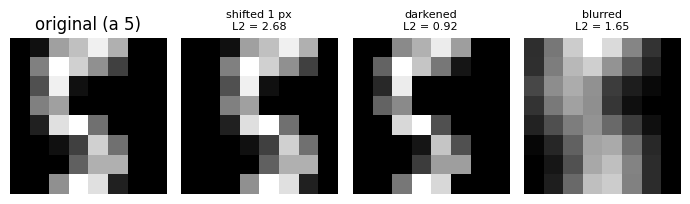

comparison                                 L2
----------------------------------------------
same image, shifted 1 px                 2.68
same image, darkened                     0.92
same image, blurred                      1.65
nearest OTHER image of the same digit    1.43
nearest image of a DIFFERENT digit       2.17


In [7]:
# pixel distance has no idea what an image means
from scipy.ndimage import shift as ndshift

img, lab = X_tr[0].reshape(8, 8), y_tr[0]
variants = {
    "shifted 1 px": ndshift(img, (0, 1), mode="nearest"),
    "darkened":     np.clip(img - 0.18, 0, 1),
    "blurred":      np.array([[img[max(0,i-1):i+2, max(0,j-1):j+2].mean()
                               for j in range(8)] for i in range(8)]),
}
fig, axes = plt.subplots(1, 4, figsize=(7, 2))
axes[0].imshow(img, cmap="gray"); axes[0].set_title(f"original (a {lab})"); axes[0].axis("off")
for ax, (name, v) in zip(axes[1:], variants.items()):
    ax.imshow(v, cmap="gray")
    ax.set_title(f"{name}\nL2 = {np.linalg.norm(v-img):.2f}", fontsize=8)
    ax.axis("off")
plt.tight_layout(); plt.show()

# how far away are REAL images, for comparison?
same  = X_tr[y_tr == lab][1:]                  # other examples of the same digit
other = X_tr[y_tr != lab]                      # every other digit
d_same  = np.linalg.norm(same  - img.ravel(), axis=1)
d_other = np.linalg.norm(other - img.ravel(), axis=1)

print(f"{'comparison':38s} {'L2':>6s}")
print("-" * 46)
for name, v in variants.items():
    print(f"same image, {name:26s} {np.linalg.norm(v-img):6.2f}")
print(f"{'nearest OTHER image of the same digit':38s} {d_same.min():6.2f}")
print(f"{'nearest image of a DIFFERENT digit':38s} {d_other.min():6.2f}")

Read those numbers carefully. Shifting this image by **one pixel** moves it *further* from
itself than the nearest image of a completely different digit. The semantic content is
untouched; the pixel distance says otherwise.

$k$-NN survives here only because 8x8 digits are nearly a toy problem. At $32\times32$ RGB
this failure is what caps it at ~38% on CIFAR-10.

**TODO 1.** Measure the curse of dimensionality yourself. For $D \in \{1, 2, 10, 100, 1000\}$,
sample 500 uniform random points in $[0,1]^D$ plus one query point, compute all distances,
and report $(d_{\max} - d_{\min}) / d_{\min}$. Plot it against $D$ on a log $x$-axis.
What does the value tell you about the meaning of "nearest" at $D = 3072$?

In [8]:
# TODO 1 -- your code here
dims = [1, 2, 10, 100, 1000]
# ...

---
## 2. The Linear Score Function

$$s = W x, \qquad W \in \mathbb{R}^{C \times D}, \quad x \in \mathbb{R}^{D}$$

(with the bias already folded into the last column of $W$, since we appended a 1 to $x$).

In [9]:
W = 0.001 * rng.standard_normal((C, D))
print("W shape:", W.shape, " X shape:", Xtr.shape)

scores = Xtr @ W.T                    # (N, C)
print("scores shape:", scores.shape)
print("\nscores for the first example:\n", scores[0])
print("predicted:", scores[0].argmax(), "   true:", y_tr[0])
print("\nAt initialization the scores are all ~0, so the prediction is arbitrary.")

W shape: (10, 65)  X shape: (1078, 65)
scores shape: (1078, 10)

scores for the first example:
 [-0.0006 -0.0013  0.0031  0.0022  0.0027  0.001  -0.0019  0.0007 -0.0013  0.0035]
predicted: 9    true: 5

At initialization the scores are all ~0, so the prediction is arbitrary.


---
## 3. The Softmax Loss

$$L_i = -\log\frac{e^{s_{y_i}}}{\sum_j e^{s_j}} = -s_{y_i} + \log\sum_j e^{s_j}$$

Write the loop version first. It is slow but transparent; the vectorized version is what
you will actually use, and you check it against the loop version.

In [10]:
def softmax_loss_naive(W, X, y, reg=0.0):
    """Explicit loops -- one example at a time."""
    N = len(X)
    loss = 0.0
    for i in range(N):
        s = X[i] @ W.T                       # (C,)
        s -= s.max()                         # numerical stability
        e = np.exp(s)
        p = e / e.sum()
        loss += -np.log(p[y[i]])
    loss /= N
    loss += reg * (W ** 2).sum()
    return loss


def softmax_loss_vectorized(W, X, y, reg=0.0):
    N = len(X)
    s = X @ W.T
    s -= s.max(axis=1, keepdims=True)
    e = np.exp(s)
    p = e / e.sum(axis=1, keepdims=True)
    loss = -np.log(p[np.arange(N), y]).mean() + reg * (W ** 2).sum()
    return loss, p                            # p is reused by the gradient

In [11]:
l_naive, t_naive = timeit(lambda: softmax_loss_naive(W, Xtr, y_tr, 1e-3))
(l_vec, _), t_vec = timeit(lambda: softmax_loss_vectorized(W, Xtr, y_tr, 1e-3))

print(f"naive      {l_naive:.10f}   ({t_naive*1000:7.2f} ms)")
print(f"vectorized {l_vec:.10f}   ({t_vec*1000:7.2f} ms, {speedup(t_naive, t_vec).strip()} faster)")
print(f"difference {abs(l_naive - l_vec):.2e}")

print(f"\nSANITY CHECK: initial loss should be ~ log(C) = {np.log(C):.4f}")
print(f"we got {l_vec:.4f}  -- {'OK' if abs(l_vec-np.log(C)) < 0.05 else 'SOMETHING IS WRONG'}")

naive      2.3023255602   (  10.44 ms)
vectorized 2.3023255602   (   0.77 ms, 13.5x faster)
difference 2.22e-15

SANITY CHECK: initial loss should be ~ log(C) = 2.3026
we got 2.3023  -- OK


That `log(C)` check is the cheapest bug detector you have. If your untrained model does not
start near 2.303 on a 10-class problem, stop and find out why before training anything.

### Numerical stability, demonstrated

In [12]:
big_scores = np.array([1000.0, 999.0, 998.0])

with np.errstate(over="ignore", invalid="ignore"):
    naive_p = np.exp(big_scores) / np.exp(big_scores).sum()
shifted = big_scores - big_scores.max()
stable_p = np.exp(shifted) / np.exp(shifted).sum()

print("without shifting:", naive_p, " <- inf/inf = nan")
print("with shifting:   ", stable_p)
print("sums to:", stable_p.sum())

without shifting: [nan nan nan]  <- inf/inf = nan
with shifting:    [0.6652 0.2447 0.09  ]
sums to: 0.9999999999999999


### The hinge loss, for comparison

In [13]:
def hinge_loss(W, X, y, reg=0.0, delta=1.0):
    N = len(X)
    s = X @ W.T
    correct = s[np.arange(N), y][:, None]
    margins = np.maximum(0, s - correct + delta)
    margins[np.arange(N), y] = 0                 # skip j = y_i
    loss = margins.sum() / N + reg * (W ** 2).sum()
    return loss, margins

hl, _ = hinge_loss(W, Xtr, y_tr)
print(f"initial hinge loss:   {hl:.4f}   (expected ~ C-1 = {C-1})")
print(f"initial softmax loss: {l_vec:.4f}   (expected ~ log C = {np.log(C):.4f})")

initial hinge loss:   8.9974   (expected ~ C-1 = 9)
initial softmax loss: 2.3023   (expected ~ log C = 2.3026)


---
## 4. Multi-Label: Independent Sigmoids

Softmax assumes **exactly one** class is correct. When an image contains several objects,
ask $C$ separate yes/no questions instead:

$$p_k = \sigma(s_k), \qquad
L = -\sum_{k=1}^{C}\big[\,y_k\log p_k + (1-y_k)\log(1-p_k)\,\big]$$

with $y \in \{0,1\}^C$ instead of a single integer.

In [14]:
def sigmoid(z):
    """Stable for large |z|: avoids exp overflow on either tail."""
    out = np.empty_like(z, dtype=float)
    pos, neg = z >= 0, z < 0
    out[pos] = 1 / (1 + np.exp(-z[pos]))
    ez = np.exp(z[neg])
    out[neg] = ez / (1 + ez)
    return out


def rel_error(a, b):
    return np.max(np.abs(a - b) / np.maximum(1e-12, np.abs(a) + np.abs(b)))


def numeric_grad(f, x, h=1e-5):
    """Centred finite differences over every entry of x."""
    g = np.zeros_like(x, dtype=float)
    it = np.nditer(x, flags=["multi_index"], op_flags=["readwrite"])
    while not it.finished:
        i = it.multi_index
        old = x[i]
        x[i] = old + h; fp = f()
        x[i] = old - h; fm = f()
        x[i] = old
        g[i] = (fp - fm) / (2 * h)
        it.iternext()
    return g


def bce_loss(S, Y):
    """S: (N, C) raw scores.  Y: (N, C) binary labels.  Returns loss, dL/dS."""
    P = sigmoid(S)
    eps = 1e-12
    per_example = -(Y * np.log(P + eps) + (1 - Y) * np.log(1 - P + eps)).sum(1)
    loss = per_example.mean()
    dS = (P - Y) / len(S)          # the SAME p - y form as softmax
    return loss, dS


# reproduce the worked example from the slides exactly
s = np.array([[2.9, 2.0, -3.5, -3.9]])
y = np.array([[1, 1, 0, 0]])
p = sigmoid(s)
terms = -(y * np.log(p) + (1 - y) * np.log(1 - p))

print("scores      ", s[0])
print("p = sigma(s)", p[0].round(4))
print("per-class   ", terms[0].round(4), "   <- -ln(p) where y=1, -ln(1-p) where y=0")
print("L = sum     ", terms.sum().round(4))
print("\nCompare softmax on the same scores: only the true class would contribute.")

scores       [ 2.9  2.  -3.5 -3.9]
p = sigma(s) [0.9478 0.8808 0.0293 0.0198]
per-class    [0.0536 0.1269 0.0298 0.02  ]    <- -ln(p) where y=1, -ln(1-p) where y=0
L = sum      0.2303

Compare softmax on the same scores: only the true class would contribute.


### The gradient is the same expression

$$\frac{\partial L}{\partial s_k} = p_k - y_k$$

for softmax **and** for BCE. Different probability model, identical gradient form -- which is
why the training loop does not change at all. Check it:

In [15]:
r = np.random.default_rng(0)
S = r.standard_normal((6, 4))
Y = (r.random((6, 4)) < 0.4).astype(float)

loss, dS = bce_loss(S, Y)
ng = numeric_grad(lambda: bce_loss(S, Y)[0], S)
print(f"BCE gradient relative error: {rel_error(dS, ng):.3e}",
      "PASS" if rel_error(dS, ng) < 1e-7 else "FAIL")
print(f"\ninitial loss with S = 0: {bce_loss(np.zeros((6, 4)), Y)[0]:.4f}")
print(f"predicted C * log 2   = {4 * np.log(2):.4f}   <- log 2 PER CLASS, not log C")

BCE gradient relative error: 4.902e-10 PASS

initial loss with S = 0: 2.7726
predicted C * log 2   = 2.7726   <- log 2 PER CLASS, not log C


### A multi-label dataset, built from digits

Overlay one, two, or three different digits into a single image. The label is the set of
digits present -- so the number of labels **varies per image**, as it does in any real
multi-label task.

5327 images, 1.82 labels per image on average
images with 1 / 2 / 3 labels: [1777 2726  824]


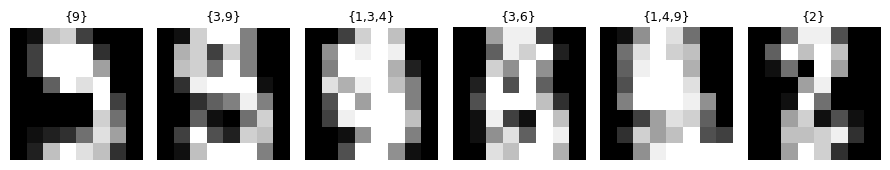

In [16]:
rng_ml = np.random.default_rng(0)
Xd_raw = digits.data / 16.0
yd_raw = digits.target
n_cls = 10

imgs, labs = [], []
for _ in range(6000):
    k = rng_ml.choice([1, 2, 3], p=[0.3, 0.5, 0.2])
    ids = rng_ml.choice(len(Xd_raw), k, replace=False)
    if len(set(yd_raw[ids])) != k:          # skip repeated digits
        continue
    imgs.append(np.maximum.reduce(Xd_raw[ids]))
    lab = np.zeros(n_cls); lab[yd_raw[ids]] = 1
    labs.append(lab)
Xml, Yml = np.array(imgs), np.array(labs)

print(f"{len(Xml)} images, {Yml.sum(1).mean():.2f} labels per image on average")
print("images with 1 / 2 / 3 labels:", np.bincount(Yml.sum(1).astype(int))[1:])

fig, axes = plt.subplots(1, 6, figsize=(9, 1.8))
for ax, im, lb in zip(axes, Xml, Yml):
    ax.imshow(im.reshape(8, 8), cmap="gray")
    ax.set_title("{" + ",".join(str(d) for d in np.where(lb)[0]) + "}", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

In [17]:
Xa, Xb, Ya, Yb = train_test_split(Xml, Yml, test_size=0.3, random_state=0)
mu_ml = Xa.mean(0)
Xa = np.hstack([Xa - mu_ml, np.ones((len(Xa), 1))])
Xb = np.hstack([Xb - mu_ml, np.ones((len(Xb), 1))])


def train_multilabel(head, iters=4000, lr=0.5, seed=0):
    r = np.random.default_rng(seed)
    W = 0.001 * r.standard_normal((n_cls, Xa.shape[1]))
    for _ in range(iters):
        i = r.choice(len(Xa), 128, replace=False)
        xb, yb = Xa[i], Ya[i]
        S = xb @ W.T
        if head == "sigmoid":
            _, dS = bce_loss(S, yb)
        else:                                  # softmax needs ONE target: split the mass
            Sm = S - S.max(1, keepdims=True)
            P = np.exp(Sm) / np.exp(Sm).sum(1, keepdims=True)
            dS = (P - yb / yb.sum(1, keepdims=True)) / len(xb)
        W -= lr * (dS.T @ xb)
    return W


W_sig = train_multilabel("sigmoid")
W_sm = train_multilabel("softmax")

P_sig = sigmoid(Xb @ W_sig.T)
Sm = Xb @ W_sm.T; Sm = Sm - Sm.max(1, keepdims=True)
P_sm = np.exp(Sm) / np.exp(Sm).sum(1, keepdims=True)

print(f"mean sum of predicted probabilities")
print(f"   sigmoid head: {P_sig.sum(1).mean():.2f}")
print(f"   softmax head: {P_sm.sum(1).mean():.2f}   (pinned to 1 by construction)")
print(f"   true mean number of labels: {Yb.sum(1).mean():.2f}")

mean sum of predicted probabilities
   sigmoid head: 1.80
   softmax head: 1.00   (pinned to 1 by construction)
   true mean number of labels: 1.81


Read those three numbers. The sigmoid head's probabilities sum to roughly the **true number
of objects in the image** -- it learned to count, because nothing stopped it. The softmax
head sums to exactly 1 whatever it sees.

In [18]:
def report(name, pred):
    tp = (pred & (Yb == 1)).sum()
    fp = (pred & (Yb == 0)).sum()
    fn = ((~pred) & (Yb == 1)).sum()
    prec, rec = tp / (tp + fp), tp / (tp + fn)
    f1 = 2 * prec * rec / (prec + rec)
    exact = (pred == (Yb == 1)).all(1).mean()
    print(f"  {name:28s} precision {prec:.3f}   recall {rec:.3f}   "
          f"F1 {f1:.3f}   exact-match {exact:.3f}")

print("sigmoid head -- threshold each class independently:")
for th in (0.3, 0.5, 0.7):
    report(f"threshold {th}", P_sig >= th)

print("\nsoftmax head -- it has to pick:")
top1 = np.zeros_like(P_sm, bool)
top1[np.arange(len(P_sm)), P_sm.argmax(1)] = True
report("argmax (its own rule)", top1)
for k in (2, 3):
    topk = np.zeros_like(P_sm, bool)
    cols = np.argsort(-P_sm, 1)[:, :k]
    topk[np.arange(len(P_sm))[:, None], cols] = True
    report(f"top-{k} (requires knowing k)", topk)

sigmoid head -- threshold each class independently:
  threshold 0.3                precision 0.737   recall 0.843   F1 0.786   exact-match 0.494
  threshold 0.5                precision 0.844   recall 0.736   F1 0.786   exact-match 0.528
  threshold 0.7                precision 0.915   recall 0.625   F1 0.743   exact-match 0.470

softmax head -- it has to pick:
  argmax (its own rule)        precision 0.926   recall 0.510   F1 0.658   exact-match 0.322
  top-2 (requires knowing k)   precision 0.698   recall 0.769   F1 0.732   exact-match 0.307
  top-3 (requires knowing k)   precision 0.533   recall 0.881   F1 0.664   exact-match 0.053


Three things worth saying out loud:

* **Softmax's own decoding rule caps its recall.** `argmax` emits one label per image while
  there are 1.8 on average, so recall cannot exceed about $1/1.8 \approx 0.55$ -- and the
  measured value sits right at that ceiling. No amount of training fixes it; it is arithmetic.
* **Top-$k$ is not a rescue.** It scores better only because we handed the model $k$, which in
  a real task is exactly what you are trying to predict. It is wrong for every image whose
  true count differs from $k$.
* **The threshold is a real knob.** Sweeping it trades precision against recall; $0.5$ is a
  default, not an answer. Tune it on validation data for the metric you actually care about.

Note also that **accuracy is the wrong metric here**. With 10 classes and ~2 positives, a
model predicting all-zeros is right on 80% of the individual $y_k$ entries. Use per-class
precision/recall, F1, or exact-match instead.

**TODO 3.** Class imbalance is severe in multi-label problems: each class is absent far more
often than it is present. Count how many positives each of the 10 digits has in your training
set, then implement **positive weighting** -- multiply the $y_k\log p_k$ term by
$w_k = (\text{negatives}_k)/(\text{positives}_k)$, as `pos_weight` does in
`nn.BCEWithLogitsLoss`. Retrain and report how precision and recall move. Which one improves,
and why would you expect that before running it?

In [19]:
# TODO 3 -- your code here

---
## 5. The Gradient

From the lecture:

$$\frac{\partial L_i}{\partial s_k} = p_k - \mathbf{1}[k = y_i]
\qquad\Longrightarrow\qquad
\nabla_W L = \frac{1}{N}(P - Y)^{\top} X + 2\lambda W$$

Implement it, then **check it** -- do not trust algebra you have not verified numerically.

In [20]:
def softmax_loss_grad(W, X, y, reg=0.0):
    N = len(X)
    loss, p = softmax_loss_vectorized(W, X, y, reg)
    dS = p.copy()
    dS[np.arange(N), y] -= 1                  # P - Y
    dW = dS.T @ X / N + 2 * reg * W
    return loss, dW

loss, dW = softmax_loss_grad(W, Xtr, y_tr, 1e-3)
print("dW shape:", dW.shape, " W shape:", W.shape, "  -- must match")

dW shape: (10, 65)  W shape: (10, 65)   -- must match


In [21]:
def grad_check(f, W, analytic, num_checks=10, h=1e-5, seed=0):
    """Compare analytic gradient against centred finite differences."""
    r = np.random.default_rng(seed)
    print(f"{'coord':>14s} {'analytic':>12s} {'numerical':>12s} {'rel error':>12s}")
    worst = 0.0
    for _ in range(num_checks):
        i, j = r.integers(W.shape[0]), r.integers(W.shape[1])
        old = W[i, j]
        W[i, j] = old + h; fp = f(W)
        W[i, j] = old - h; fm = f(W)
        W[i, j] = old
        num = (fp - fm) / (2 * h)
        ana = analytic[i, j]
        rel = abs(ana - num) / max(abs(ana), abs(num), 1e-12)
        worst = max(worst, rel)
        print(f"({i:2d},{j:3d})     {ana:12.8f} {num:12.8f} {rel:12.2e}")
    print(f"\nworst relative error: {worst:.2e}", end="  ")
    print("-- PASS" if worst < 1e-6 else "-- FAIL, the gradient is wrong")
    return worst


print("=== without regularization ===")
loss, dW = softmax_loss_grad(W, Xtr, y_tr, 0.0)
grad_check(lambda Wx: softmax_loss_vectorized(Wx, Xtr, y_tr, 0.0)[0], W, dW)

print("\n=== with regularization (catches a forgotten 2*reg*W term) ===")
loss, dW = softmax_loss_grad(W, Xtr, y_tr, 1e-1)
grad_check(lambda Wx: softmax_loss_vectorized(Wx, Xtr, y_tr, 1e-1)[0], W, dW)

=== without regularization ===
         coord     analytic    numerical    rel error
( 8, 41)       0.00250835   0.00250835     5.08e-09
( 5, 17)      -0.01927385  -0.01927385     2.57e-10
( 3,  2)      -0.02203051  -0.02203051     1.68e-10
( 0,  1)       0.00181511   0.00181511     1.87e-09
( 1, 52)      -0.02351399  -0.02351399     3.27e-10
( 6, 59)       0.00924219   0.00924219     2.49e-11
( 5, 39)       0.00000000   0.00000000     0.00e+00
( 9, 47)       0.00012803   0.00012803     1.10e-07
( 6, 35)      -0.02487669  -0.02487669     5.46e-10
( 5, 60)       0.01526465   0.01526465     6.14e-11

worst relative error: 1.10e-07  -- PASS

=== with regularization (catches a forgotten 2*reg*W term) ===
         coord     analytic    numerical    rel error
( 8, 41)       0.00243289   0.00243289     4.39e-09
( 5, 17)      -0.01898128  -0.01898128     3.30e-10
( 3,  2)      -0.02214764  -0.02214764     6.67e-10
( 0,  1)       0.00178869   0.00178869     2.59e-10
( 1, 52)      -0.02336877  -

np.float64(5.485750776108824e-08)

**TODO 4.** Deliberately break the gradient and watch the check catch it. Write
`softmax_loss_grad_buggy` that forgets the `-1` on the correct class (i.e. returns
`p.T @ X / N` instead of `(p - Y).T @ X / N`), run `grad_check` on it, and report the
relative error. Then break it a second way -- forget to divide by `N` -- and note how the
two failures look different.

In [22]:
# TODO 4 -- your code here
def softmax_loss_grad_buggy(W, X, y, reg=0.0):
    ...

**TODO 5.** Derive and implement the **hinge** gradient. From the lecture:

$$\nabla_{w_j} L_i = \mathbf{1}[\text{margin}_j > 0]\, x_i \quad (j \neq y_i),
\qquad \nabla_{w_{y_i}} L_i = -\Big(\sum_{j \neq y_i}\mathbf{1}[\text{margin}_j > 0]\Big) x_i$$

`hinge_loss` above already returns the `margins` matrix, which is nonzero exactly where a
margin is violated. Build a binary mask from it, set the correct-class column to minus the
row sum, and you are done in three lines. Then gradient-check it.

*Expect a slightly worse relative error than softmax -- the hinge has kinks, and the
numerical gradient is inaccurate near them. That is not a bug.*

In [23]:
# TODO 5 -- your code here
def hinge_loss_grad(W, X, y, reg=0.0, delta=1.0):
    ...

---
## 6. Training with SGD

The twelve lines from the lecture, with bookkeeping added.

final: loss 0.1492   train 0.9870   val 0.9749


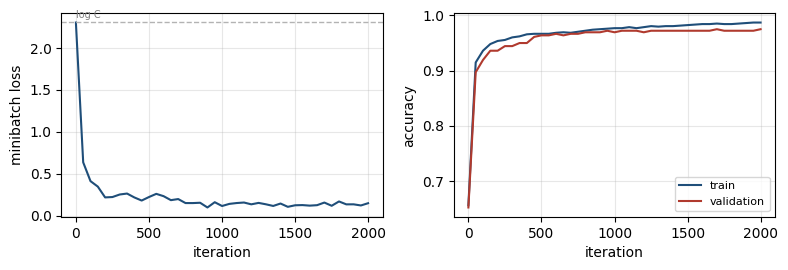

In [24]:
def train(X, y, Xv, yv, reg=1e-4, lr=0.5, iters=1500, batch=128, seed=0, verbose=True):
    r = np.random.default_rng(seed)
    W = 0.001 * r.standard_normal((C, X.shape[1]))
    hist = {"iter": [], "loss": [], "train_acc": [], "val_acc": []}
    for t in range(iters):
        idx = r.choice(len(X), batch, replace=False)
        loss, dW = softmax_loss_grad(W, X[idx], y[idx], reg)
        W -= lr * dW
        if t % 50 == 0 or t == iters - 1:
            hist["iter"].append(t)
            hist["loss"].append(loss)
            hist["train_acc"].append(((X @ W.T).argmax(1) == y).mean())
            hist["val_acc"].append(((Xv @ W.T).argmax(1) == yv).mean())
    if verbose:
        print(f"final: loss {hist['loss'][-1]:.4f}   "
              f"train {hist['train_acc'][-1]:.4f}   val {hist['val_acc'][-1]:.4f}")
    return W, hist


W_trained, hist = train(Xtr, y_tr, Xval, y_val, reg=1e-4, lr=0.5, iters=2000)

fig, ax = plt.subplots(1, 2, figsize=(8, 2.8))
ax[0].plot(hist["iter"], hist["loss"], color="#1F4E79")
ax[0].set_xlabel("iteration"); ax[0].set_ylabel("minibatch loss")
ax[0].axhline(np.log(C), color="0.7", ls="--", lw=1)
ax[0].text(0, np.log(C) + .05, "log C", fontsize=7, color="0.5")
ax[0].grid(alpha=.3)
ax[1].plot(hist["iter"], hist["train_acc"], label="train", color="#1F4E79")
ax[1].plot(hist["iter"], hist["val_acc"], label="validation", color="#B03A2E")
ax[1].set_xlabel("iteration"); ax[1].set_ylabel("accuracy")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

### The learning rate

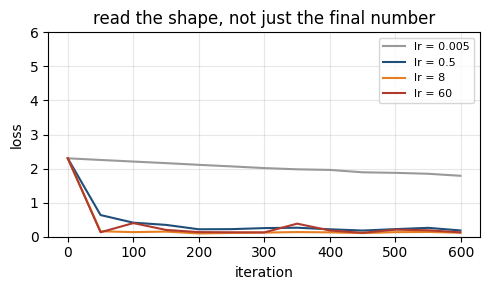

In [25]:
plt.figure(figsize=(5, 3))
for lr, col in [(0.005, "0.6"), (0.5, "#1F4E79"), (8.0, "#E67E22"), (60.0, "#B03A2E")]:
    _, h = train(Xtr, y_tr, Xval, y_val, lr=lr, iters=600, verbose=False)
    plt.plot(h["iter"], np.minimum(h["loss"], 20), label=f"lr = {lr:g}", color=col)
plt.ylim(0, 6); plt.xlabel("iteration"); plt.ylabel("loss")
plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.title("read the shape, not just the final number")
plt.tight_layout(); plt.show()

Learn to read these shapes -- they are the fastest diagnostic you have:

* **flat and high** -- learning rate far too low, or the gradient is broken
* **drops then plateaus early** -- rate slightly too high, or time to decay it
* **noisy but descending** -- healthy
* **spikes to `nan`** -- rate far too high

### Regularization sweep

best lambda = 1.0e-06   validation accuracy = 0.9721


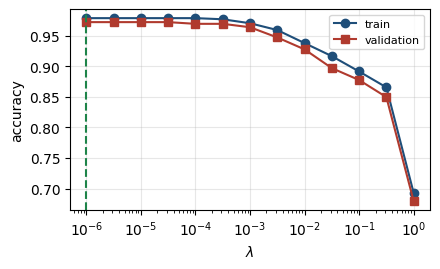

In [26]:
lams = np.logspace(-6, 0, 13)
tr_acc, va_acc = [], []
for lam in lams:
    Wl, _ = train(Xtr, y_tr, Xval, y_val, reg=lam, lr=0.5, iters=1200, verbose=False)
    tr_acc.append(((Xtr @ Wl.T).argmax(1) == y_tr).mean())
    va_acc.append(((Xval @ Wl.T).argmax(1) == y_val).mean())

best = lams[int(np.argmax(va_acc))]
print(f"best lambda = {best:.1e}   validation accuracy = {max(va_acc):.4f}")
if best in (lams[0], lams[-1]):
    print("WARNING: the best value is at the edge of the grid -- extend the range.")

plt.figure(figsize=(4.5, 2.8))
plt.semilogx(lams, tr_acc, "o-", label="train", color="#1F4E79")
plt.semilogx(lams, va_acc, "s-", label="validation", color="#B03A2E")
plt.axvline(best, color="#1E8449", ls="--")
plt.xlabel(r"$\lambda$"); plt.ylabel("accuracy"); plt.legend(fontsize=8)
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

---
## 7. Looking at What It Learned

Each row of $W$ has the same shape as an image. Reshape it and look.

final: loss 0.0790   train 0.9907   val 0.9777


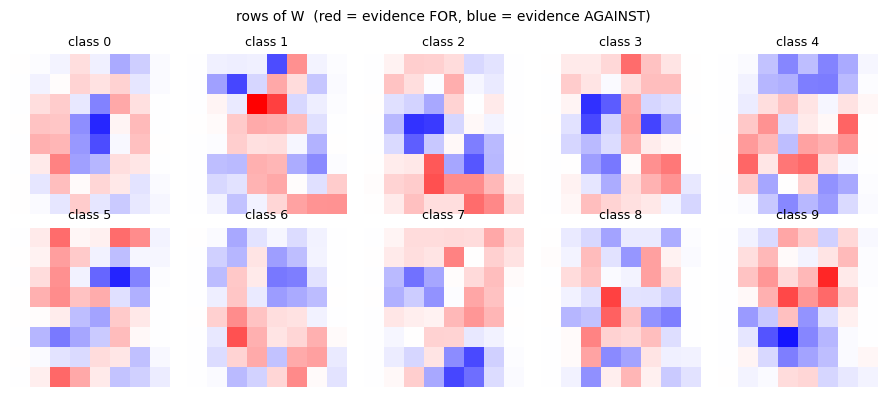

In [27]:
W_best, _ = train(Xtr, y_tr, Xval, y_val, reg=best, lr=0.5, iters=3000)

lim = np.abs(W_best[:, :64]).max()
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for c, ax in enumerate(axes.ravel()):
    ax.imshow(W_best[c, :64].reshape(8, 8), cmap="bwr", vmin=-lim, vmax=lim)
    ax.set_title(f"class {c}", fontsize=9); ax.axis("off")
plt.suptitle("rows of W  (red = evidence FOR, blue = evidence AGAINST)", fontsize=10)
plt.tight_layout(); plt.show()

TEST accuracy: 0.9667


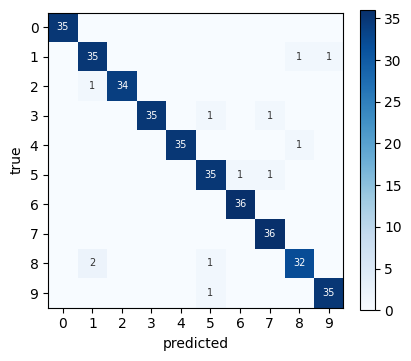

most common confusion: true 8 predicted as 1  (2 times)


In [28]:
# test accuracy -- looked at exactly once, now that every choice is made
test_acc = ((Xte @ W_best.T).argmax(1) == y_te).mean()
print(f"TEST accuracy: {test_acc:.4f}")

pred = (Xte @ W_best.T).argmax(1)
M = np.zeros((C, C), int)
for t, p in zip(y_te, pred):
    M[t, p] += 1

fig, ax = plt.subplots(figsize=(4.2, 3.8))
im = ax.imshow(M, cmap="Blues")
for i in range(C):
    for j in range(C):
        if M[i, j]:
            ax.text(j, i, M[i, j], ha="center", va="center", fontsize=7,
                    color="white" if M[i, j] > M.max() * .5 else "0.2")
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_xticks(range(C)); ax.set_yticks(range(C))
plt.colorbar(im, fraction=.046); plt.tight_layout(); plt.show()

off = M - np.diag(np.diag(M))
i, j = np.unravel_index(off.argmax(), off.shape)
print(f"most common confusion: true {i} predicted as {j}  ({off[i,j]} times)")

---
## 8. The Sanity Check
Turn regularization off, take 20 examples, and train until the model memorizes them.
A correct model with a correct gradient **will** reach 100%. If it cannot, something is
broken, and no amount of hyperparameter tuning will fix it.

accuracy on the 20 memorized examples: 100.00%
PASS -- model and gradient are wired up correctly


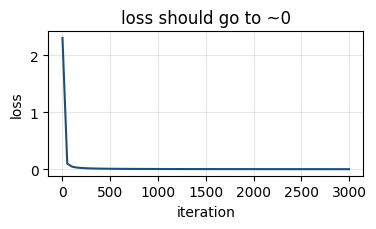

In [29]:
n_tiny = 20
Xtiny, ytiny = Xtr[:n_tiny], y_tr[:n_tiny]

W_tiny, h_tiny = train(Xtiny, ytiny, Xtiny, ytiny, reg=0.0, lr=1.0,
                       iters=3000, batch=n_tiny, verbose=False)
acc = ((Xtiny @ W_tiny.T).argmax(1) == ytiny).mean()
print(f"accuracy on the 20 memorized examples: {acc:.2%}")
print("PASS -- model and gradient are wired up correctly"
      if acc == 1.0 else "FAIL -- stop and debug before doing anything else")

plt.figure(figsize=(4, 2.4))
plt.plot(h_tiny["iter"], h_tiny["loss"], color="#1F4E79")
plt.xlabel("iteration"); plt.ylabel("loss"); plt.grid(alpha=.3)
plt.title("loss should go to ~0"); plt.tight_layout(); plt.show()

---
## 9. The Same Thing in PyTorch

Everything you wrote above, in eight lines. Note what disappears: the loss derivative,
the gradient check, the manual update.

*(Needs `torch`. Skip if not installed.)*

In [30]:
import torch
import torch.nn as nn

Xt = torch.tensor(X_tr - mu, dtype=torch.float32)     # no bias column: nn.Linear has one
yt = torch.tensor(y_tr, dtype=torch.long)
Xv = torch.tensor(X_val - mu, dtype=torch.float32)
yv = torch.tensor(y_val, dtype=torch.long)

torch.manual_seed(0)
model = nn.Linear(64, C)
opt = torch.optim.SGD(model.parameters(), lr=0.5, weight_decay=2 * float(best))
lossf = nn.CrossEntropyLoss()                    # takes RAW scores, not probabilities

print(f"initial loss: {lossf(model(Xt), yt).item():.4f}   "
      f"(expected ~ log C = {np.log(C):.4f})")

for t in range(2000):
    idx = torch.randint(0, len(Xt), (128,))
    opt.zero_grad()
    loss = lossf(model(Xt[idx]), yt[idx])
    loss.backward()
    opt.step()

with torch.no_grad():
    acc = (model(Xv).argmax(1) == yv).float().mean().item()
print(f"\nPyTorch validation accuracy: {acc:.4f}")
print(f"NumPy   validation accuracy: {((Xval @ W_best.T).argmax(1) == y_val).mean():.4f}")

initial loss: 2.3091   (expected ~ log C = 2.3026)

PyTorch validation accuracy: 0.9777
NumPy   validation accuracy: 0.9777


In [31]:
# the gradient PyTorch computes is the one you derived
model.zero_grad()
lossf(model(Xt[:64]), yt[:64]).backward()
torch_grad = model.weight.grad.numpy()

Wnp = np.hstack([model.weight.detach().numpy(),
                 model.bias.detach().numpy()[:, None]])
_, my_grad = softmax_loss_grad(Wnp, Xtr[:64], y_tr[:64], 0.0)

print("max |torch grad - my grad|:", np.abs(torch_grad - my_grad[:, :64]).max())
print("=> autograd is doing exactly the algebra from section 4.")

max |torch grad - my grad|: 8.33209078023988e-09
=> autograd is doing exactly the algebra from section 4.


---
## Exercises

**1. $k$-NN, honestly evaluated.** Implement 5-fold cross-validation over
$k \in \{1,3,5,\dots,50\}$ using only the training set. Plot mean accuracy with error bars
(std across folds). Then answer: is the best $k$ actually better than its neighbours, or is
the difference inside the error bars? Report a single test number for your chosen $k$, once.

**2. Hinge vs softmax, measured.** Complete `hinge_loss_grad` from TODO 3 and train both
losses with identical settings. Compare final validation accuracy, the loss curves, and the
weight templates. Then check the claim from the lecture: for correctly-classified examples
past the margin, count how many have exactly zero gradient under hinge, and under softmax.

**3. Preprocessing matters.** Train three models: raw pixels, mean-subtracted, and fully
standardized (divide by per-feature std, guarding against zero-variance pixels -- the
corners of a digit image are always black). Use the same learning rate for all three.
Which converges fastest, and which needs a different learning rate to work at all?
Explain the result in terms of the shape of the loss surface.

**4. The template limitation.** Train on digits, then evaluate on a **rotated** test set
(rotate each test image by 15 degrees; `scipy.ndimage.rotate` with `reshape=False`).
Report the accuracy drop. Then augment the *training* set with rotated copies, retrain, and
look at the learned templates -- they get blurrier. Explain why, in terms of "one template
per class".

**5. Two-layer preview.** Replace $s = Wx$ with $s = W_2\max(0, W_1x)$ where $W_1$ is
$64 \times 30$. You do not need to derive the gradient by hand -- use PyTorch. Compare
against the linear model on digits, and then on a dataset a linear model genuinely cannot
solve: `sklearn.datasets.make_circles(n_samples=1000, factor=0.4, noise=0.1)`. Report both.
The gap on the second dataset is exactly what Week 4 is about.